In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx

In [2]:
gdf = gpd.read_file('tl_2025_36_tabblock20/tl_2025_36_tabblock20.shp')

print(gdf.columns)
print(gdf.head())

Index(['STATEFP20', 'COUNTYFP20', 'TRACTCE20', 'BLOCKCE20', 'GEOID20',
       'GEOIDFQ20', 'NAME20', 'MTFCC20', 'UR20', 'UACE20', 'FUNCSTAT20',
       'ALAND20', 'AWATER20', 'INTPTLAT20', 'INTPTLON20', 'HOUSING20', 'POP20',
       'geometry'],
      dtype='str')
  STATEFP20 COUNTYFP20 TRACTCE20 BLOCKCE20          GEOID20  \
0        36        069    051600      2006  360690516002006   
1        36        069    051501      2025  360690515012025   
2        36        069    051501      2033  360690515012033   
3        36        069    050205      1013  360690502051013   
4        36        069    051900      2026  360690519002026   

                  GEOIDFQ20      NAME20 MTFCC20 UR20 UACE20 FUNCSTAT20  \
0  1000000US360690516002006  Block 2006   G5040    U  32842          S   
1  1000000US360690515012025  Block 2025   G5040    U  32842          S   
2  1000000US360690515012033  Block 2033   G5040    U  32842          S   
3  1000000US360690502051013  Block 1013   G5040    U  75664   

In [3]:
gdf_3857 = gdf.to_crs(epsg = "3857", inplace = False)

In [5]:
nyc_counties = ['005', '047', '061', '081', '085']

nyc_gdf = gdf_3857[
    (gdf_3857['COUNTYFP20'].isin(nyc_counties))
]

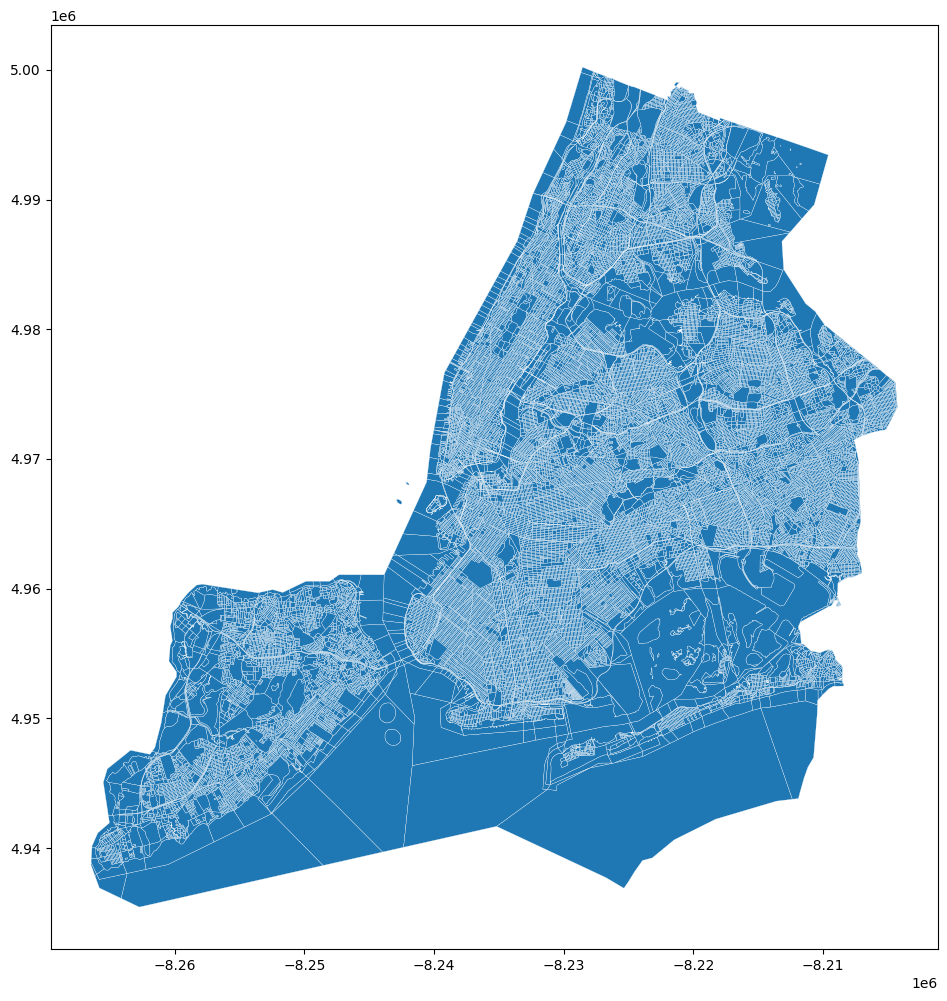

In [6]:
fig, ax = plt.subplots(figsize=(12, 12))

nyc_gdf.plot(ax=ax, legend=True, edgecolor='white', linewidth=0.2)

plt.show()

In [7]:
nyc_gdf['centroid'] = nyc_gdf.geometry.centroid

# nyc_gdf['centroid'] = nyc_gdf.geometry.representative_point()

nyc_gdf['x'] = nyc_gdf.centroid.x
nyc_gdf['y'] = nyc_gdf.centroid.y

<Axes: >

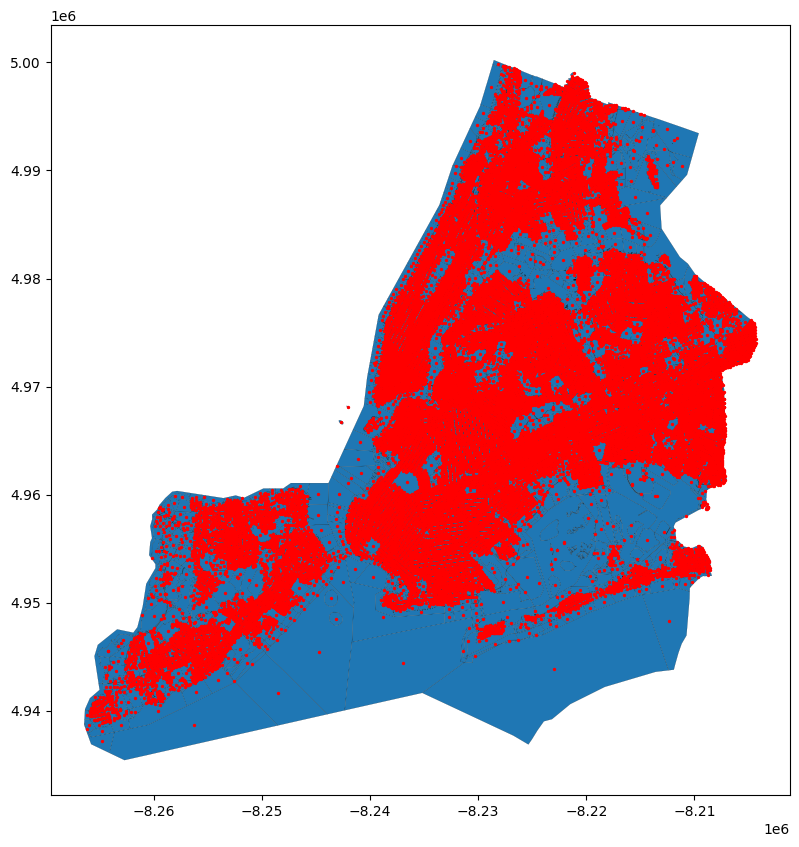

In [8]:
ax = nyc_gdf.plot(figsize=(10, 10), edgecolor='black', linewidth=0.1)
nyc_gdf.centroid.plot(ax=ax, color='red', markersize=2)

In [11]:
from shapely.geometry import box

sindex = nyc_gdf.sindex

import networkx as nx

G = nx.Graph()
nyc_gdf = nyc_gdf.reset_index(drop=True)

# Add nodes
for idx, row in nyc_gdf.iterrows():
    G.add_node(row['GEOID20'], pos=(row['x'], row['y']))

sindex = nyc_gdf.sindex

for idx, geom in nyc_gdf.geometry.items():
    geoid = nyc_gdf.loc[idx, 'GEOID20']
    
    possible_matches_idx = list(sindex.intersection(geom.bounds))
    
    for j in possible_matches_idx:
        if idx == j:
            continue
        
        neighbor_geom = nyc_gdf.geometry.iloc[j]
        neighbor_geoid = nyc_gdf['GEOID20'].iloc[j]
        
        if geom.touches(neighbor_geom):
            G.add_edge(geoid, neighbor_geoid)

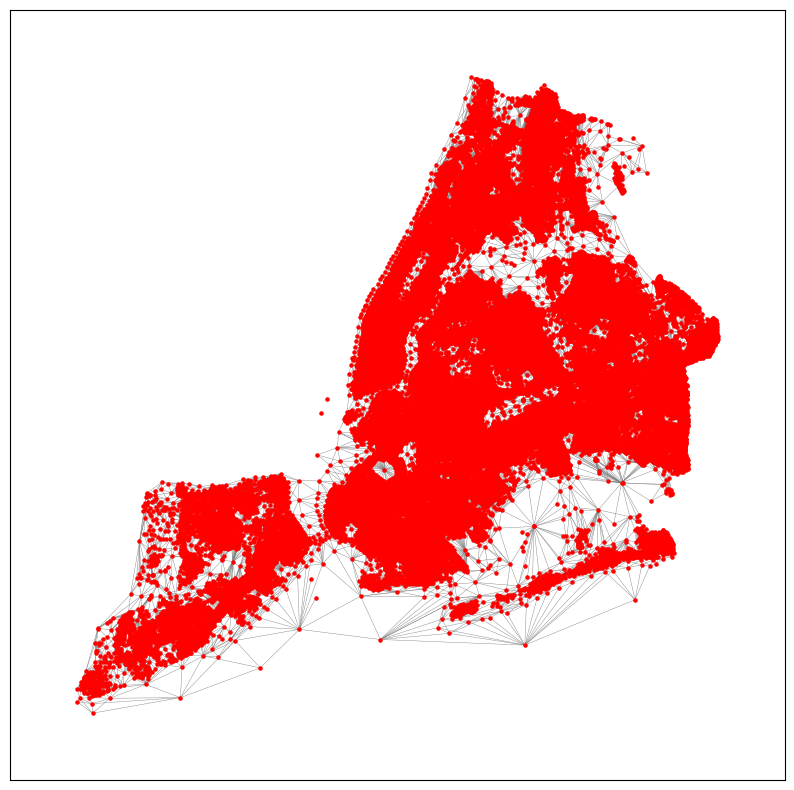

In [12]:
pos = nx.get_node_attributes(G, 'pos')

fig, ax = plt.subplots(figsize=(10, 10))

nx.draw_networkx_edges(G, pos, ax=ax, width=0.3, edge_color='gray')

nx.draw_networkx_nodes(G, pos, ax=ax, node_size=5, node_color='red')

plt.show()